In [8]:
%pip install -q -U pandas matplotlib seaborn tensorflow numpy scikit-learn

Note: you may need to restart the kernel to use updated packages.


# Lizard Images Classification - Exploratory Data Analysis (EDA)
This notebook covers the initial deep learning steps for the lizard classification challenge, including EDA and baseline model setup using TensorFlow and Keras.

## 1. Import Required Libraries

In [9]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


## 2. Define Dataset Paths and Inspect Data
Let's check the available folders and load the `train.csv`.

In [10]:
base_path = '.'
train_dir = os.path.join(base_path, 'train')
test_dir = os.path.join(base_path, 'test')

train_df = pd.read_csv(os.path.join(base_path, 'train.csv'))
display(train_df.head())
print("Total training records:", len(train_df))

,id,label
0,Black_spiny-tailed_iguana_Black_spiny-tailed_i...,0
1,Black_spiny-tailed_iguana_Black_spiny-tailed_i...,0
2,Black_spiny-tailed_iguana_Black_spiny-tailed_i...,0
3,Black_spiny-tailed_iguana_Black_spiny-tailed_i...,0
4,Black_spiny-tailed_iguana_Black_spiny-tailed_i...,0


Total training records: 1334


## 3. Exploratory Data Analysis (EDA)
Checking class distribution from the subset.

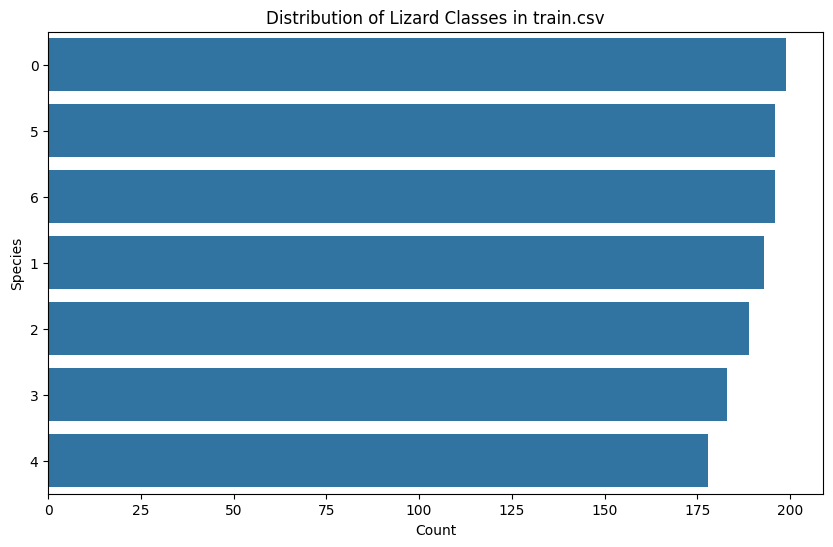

In [11]:
plt.figure(figsize=(10, 6))
# Assuming there's a 'label' or 'class' column. Adjust as per actual train.csv schema.
sns.countplot(data=train_df, y=train_df.columns[1], order=train_df.iloc[:, 1].value_counts().index)
plt.title('Distribution of Lizard Classes in train.csv')
plt.xlabel('Count')
plt.ylabel('Species')
plt.show()

## 4. Setting up TensorFlow Image Data Generators/Datasets
Loading the images directly from the `train/` directory utilizing Keras utilities.

In [12]:
IMG_SIZE = (224, 224) # Standard for most pre-trained models
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
print("Classes found:", class_names)

Found 1334 files belonging to 7 classes.


Using 1068 files for training.
Found 1334 files belonging to 7 classes.
Using 266 files for validation.
Classes found: ['Black_spiny_tailed_iguana', 'Brown_anole', 'Cuban_knight_anole', 'Desert_iguana', 'Green_anole', 'Green_iguana', 'Lesser_Antillean_iguana']


## Visualizing sample images

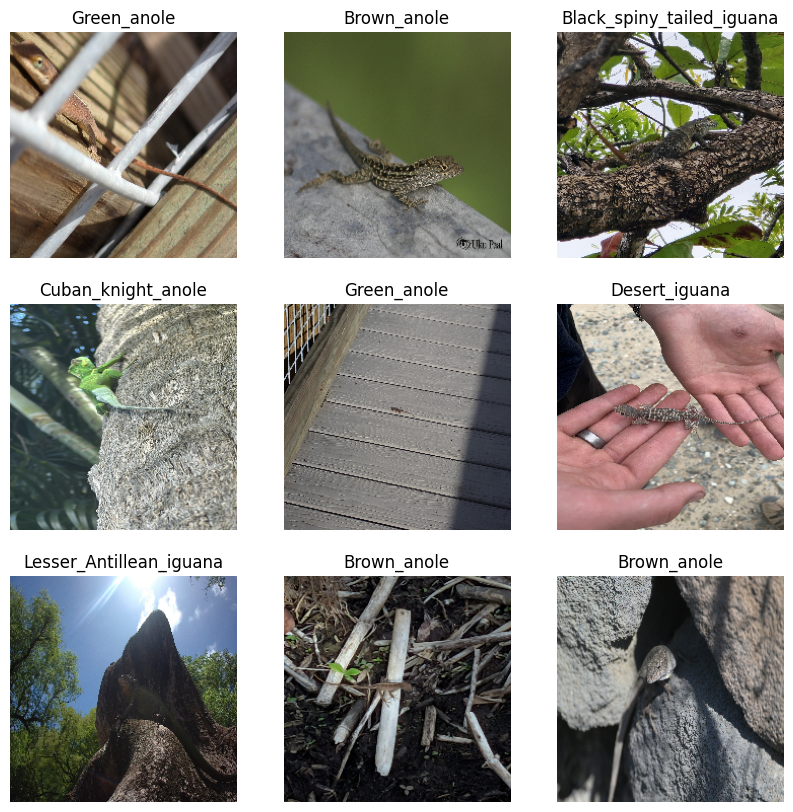

In [13]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

## 5. Performance Optimization & Data Augmentation
Prefetching the datasets and applying basic augmentation.

In [14]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
])

## 6. Build the TensorFlow Keras Model
Creating a basic CNN. Next step might evaluate using Transfer Learning like ResNet50 or MobileNetV2 depending on your requirements.

In [15]:
num_classes = len(class_names)

# Use MobileNetV2 for Transfer Learning
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
    include_top=False,
    weights='imagenet'
)
# Freeze the base model
base_model.trainable = False

model = keras.Sequential([
    data_augmentation,
    # MobileNetV2 expects pixel values in [-1, 1], but preprocess_input handles it.
    layers.Lambda(tf.keras.applications.mobilenet_v2.preprocess_input),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.2),
    layers.Dense(num_classes, name="outputs")
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ outputs (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

## 7. Compile and Train the Model

In [16]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

# Implement Learning Rate Scheduler & Early Stopping
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                                 patience=3, min_lr=1e-6, verbose=1)

early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=6, 
                                                  restore_best_weights=True, verbose=1)

# Increase epochs since we have early stopping to prevent over-training
epochs = 20
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs,
  callbacks=[reduce_lr, early_stopping]
)

Epoch 1/20

34/34 ━━━━━━━━━━━━━━━━━━━━ 14s 255ms/step - accuracy: 0.2444 - loss: 2.0231 - val_accuracy: 0.3684 - val_loss: 1.5652 - learning_rate: 0.0010
Epoch 2/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 8s 233ms/step - accuracy: 0.3970 - loss: 1.5661 - val_accuracy: 0.4436 - val_loss: 1.4471 - learning_rate: 0.0010
Epoch 3/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 8s 240ms/step - accuracy: 0.4757 - loss: 1.3858 - val_accuracy: 0.4624 - val_loss: 1.3407 - learning_rate: 0.0010
Epoch 4/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 8s 235ms/step - accuracy: 0.4878 - loss: 1.3376 - val_accuracy: 0.5113 - val_loss: 1.2558 - learning_rate: 0.0010
Epoch 5/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 8s 230ms/step - accuracy: 0.5365 - loss: 1.2549 - val_accuracy: 0.5226 - val_loss: 1.3317 - learning_rate: 0.0010
Epoch 6/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 8s 236ms/step - accuracy: 0.5506 - loss: 1.1499 - val_accuracy: 0.5301 - val_loss: 1.2295 - learning_rate: 0.0010
Epoch 7/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 8s 232ms/step - accuracy: 0.5852 - loss: 1.1121 

## 7b. Fine-Tuning the Base Model
To improve accuracy past the ~57% mark, we can unfreeze the top layers of the previously fully-frozen MobileNetV2 base model. This allows the model to adjust generalized features (like edges and shapes) explicitly to the textures and patterns of lizard species. We must compile it again with a significantly lower learning rate so we don't wreck the pretrained weights.

In [17]:
# Unfreeze the base model
base_model.trainable = True

# Optional: Fine-tune from this layer onwards. MobileNetV2 has > 150 layers.
# Let's freeze the first 100 layers and unfreeze the rest
fine_tune_at = 100
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# Recompile the model with a much lower learning rate (e.g., 1e-5 instead of default 1e-3)
model.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
              metrics=['accuracy'])

model.summary()

# Continue training from where we left off
fine_tune_epochs = 15
total_epochs =  epochs + fine_tune_epochs

history_fine = model.fit(
    train_ds,
    epochs=total_epochs,
    initial_epoch=history.epoch[-1], # start from the last epoch
    validation_data=val_ds,
    callbacks=[reduce_lr, early_stopping]
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ outputs (Dense)                 │ (None, 7)              │         8,967 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,266,951 (8.65 MB)

 Trainable params: 1,870,407 (7.14 MB)

 Non-trainable params: 396,544 (1.51 MB)

Epoch 20/35
34/34 ━━━━━━━━━━━━━━━━━━━━ 17s 335ms/step - accuracy: 0.4579 - loss: 1.4372 - val_accuracy: 0.5677 - val_loss: 1.1577 - learning_rate: 1.0000e-05
Epoch 21/35
34/34 ━━━━━━━━━━━━━━━━━━━━ 11s 323ms/step - accuracy: 0.5318 - loss: 1.2451 - val_accuracy: 0.5752 - val_loss: 1.1560 - learning_rate: 1.0000e-05
Epoch 22/35
34/34 ━━━━━━━━━━━━━━━━━━━━ 11s 336ms/step - accuracy: 0.5665 - loss: 1.1593 - val_accuracy: 0.5677 - val_loss: 1.1537 - learning_rate: 1.0000e-05
Epoch 23/35
34/34 ━━━━━━━━━━━━━━━━━━━━ 11s 312ms/step - accuracy: 0.5449 - loss: 1.1680 - val_accuracy: 0.5714 - val_loss: 1.1489 - learning_rate: 1.0000e-05
Epoch 24/35
34/34 ━━━━━━━━━━━━━━━━━━━━ 11s 310ms/step - accuracy: 0.5918 - loss: 1.1017 - val_accuracy: 0.5714 - val_loss: 1.1444 - learning_rate: 1.0000e-05
Epoch 25/35
34/34 ━━━━━━━━━━━━━━━━━━━━ 11s 311ms/step - accuracy: 0.5946 - loss: 1.0594 - val_accuracy: 0.5789 - val_loss: 1.1389 - learning_rate: 1.0000e-05
Epoch 26/35
34/34 ━━━━━━━━━━━━━━━━━━━━ 11s 312ms/ste

In [18]:
# Extract the initial history from phase 1
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

# Merge the history dictionaries so our plots in section 8 remain completely accurate
acc += history_fine.history['accuracy']
val_acc += history_fine.history['val_accuracy']
loss += history_fine.history['loss']
val_loss += history_fine.history['val_loss']

# Update total epochs run for plotting
epochs_range = range(len(acc))

## 8. Evaluate Training Performance

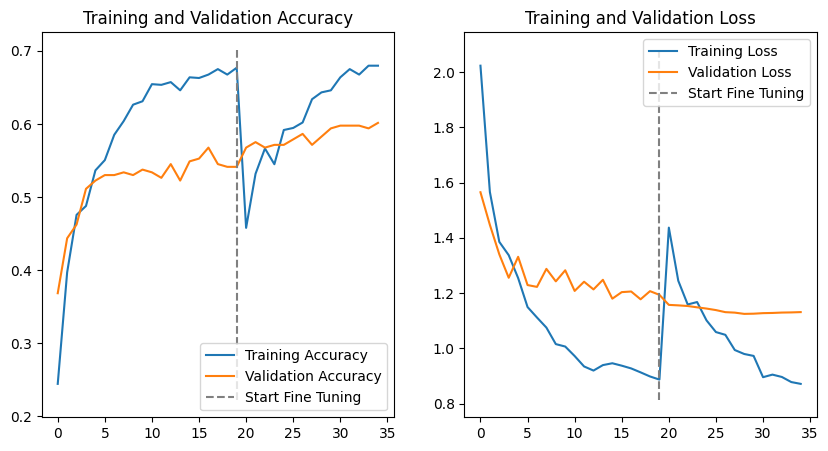

In [19]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.plot([history.epoch[-1], history.epoch[-1]], 
         plt.ylim(), label='Start Fine Tuning', ls='--', color='gray')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.plot([history.epoch[-1], history.epoch[-1]], 
         plt.ylim(), label='Start Fine Tuning', ls='--', color='gray')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

## 9. Confusion Matrix
Evaluating the model using a confusion matrix on the validation set to see exactly where the model gets confused between species.

9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 220ms/step


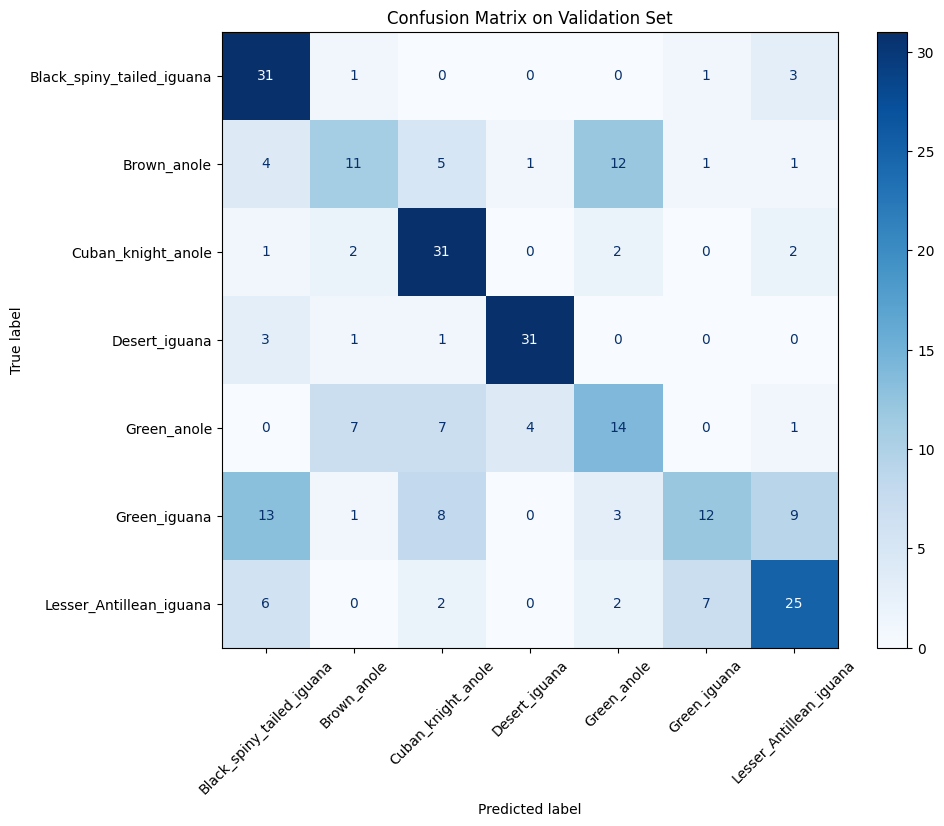

In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Get predictions on the validation dataset
val_images = []
val_labels = []

for images, labels in val_ds:
    val_images.append(images)
    val_labels.append(labels)
    
val_images = tf.concat(val_images, axis=0)
val_labels = tf.concat(val_labels, axis=0)

val_predictions = model.predict(val_images)
val_pred_classes = np.argmax(val_predictions, axis=1)

# Generate and plot the confusion matrix
cm = confusion_matrix(val_labels, val_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

plt.figure(figsize=(10, 8))
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45, ax=plt.gca())
plt.title('Confusion Matrix on Validation Set')
plt.show()

## 10. Kaggle Submission Generation
Preparing predictions for the test dataset and structuring them to match `sample_submission.csv`.

In [21]:
# Load test set (adjust if you need a specialized loader depending on Kaggle's test format)
# Assuming test images are directly in the test/ folder (meaning we need to construct a dataset manually or load images dynamically).
import glob
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# Read submission template
submission_df = pd.read_csv(os.path.join(base_path, 'sample_submission.csv'))

# Create empty lists for predictions
test_ids = []
pred_labels = []

for idx, row in submission_df.iterrows():
    # Construct image path based on sample_submission logic. Usually it's id + .jpg
    # Replace the extension logic depending on the exact test image format.
    img_name = str(row['id']) + '.jpg'  
    img_path = os.path.join(test_dir, img_name)
    
    if os.path.exists(img_path):
        img = load_img(img_path, target_size=IMG_SIZE)
        img_arr = img_to_array(img)
        img_arr = tf.expand_dims(img_arr, 0) # Create a batch
        
        preds = model.predict(img_arr, verbose=0)
        pred_class_idx = np.argmax(preds, axis=1)[0]
        # Since class_names is sorted alphanumerically, the index perfectly matches the Kaggle integer categories 0-6
        pred_labels.append(pred_class_idx)
    else:
        # Fallback if image not found
        pred_labels.append(0) 

submission_df['label'] = pred_labels
submission_df.to_csv('submission.csv', index=False)
print("Saved final predictions to submission.csv successfully!")
display(submission_df.head())

Saved final predictions to submission.csv successfully!


,id,label
0,1,6
1,2,5
2,3,0
3,4,0
4,5,0
